# Matrix Spike (MS) Per-Analyte Time-Series Analysis

## Purpose

This notebook explores the historical time-series behaviour of Matrix Spike (MS) QC results.

The aim is to:

- visualise Matrix Spike results through time;
- examine behaviour separately for different analytes;
- retain relevant analytical context for each MS result;
- examine historical variation in Matrix Spike behaviour;
- identify descriptive differences in historical behaviour between analytes;
- provide historical context for the subsequent drift-detection task.

This notebook is exploratory and descriptive only.

It does not create new anomaly or drift classifications.

## 1. Import Libraries

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Matrix Spike Data

In [87]:
from pathlib import Path

# Search the repository for the QC Anomaly Training Data workbook
search_locations = [
    Path("."),
    Path("..")
]

matches = []

for location in search_locations:
    matches.extend(
        location.rglob("QC Anomaly Training Data*.xlsx")
    )

# Remove duplicate paths
matches = list(dict.fromkeys(matches))

if len(matches) == 0:
    raise FileNotFoundError(
        "Could not find a QC Anomaly Training Data Excel workbook."
    )

print("Matching files found:")
for i, file in enumerate(matches):
    print(i, file)

data_file = matches[0]

print("\nUsing file:", data_file)

Matching files found:
0 ../data/raw/QC Anomaly Training Data v2 (1).xlsx

Using file: ../data/raw/QC Anomaly Training Data v2 (1).xlsx


In [88]:
ms = pd.read_excel(
    data_file,
    sheet_name="SPK(MS) Assessment"
)

# Remove completely empty columns
ms = ms.dropna(axis=1, how="all")

print("Matrix Spike rows:", len(ms))
print("Useful columns:", len(ms.columns))

display(ms.head())

Matrix Spike rows: 6958
Useful columns: 25


,ANALYTICAL_TYPE,QC_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,...,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MIN_WARNING_INCLUSIVE,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,UNIT_CODE,SPECIFICATION_CODE
0,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0010007372,0.093486,2021-06-08 16:35:31,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C
1,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0009017856,0.100020,2021-05-10 15:11:04,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C
2,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0009017856,0.103217,2021-05-07 12:18:32,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C
3,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0009017856,0.062144,2021-05-05 10:31:07,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C
4,Spike,MS,OREAS_502C,OREAS_502C,TSV_LB0006998356,0.091200,2021-03-03 13:04:39,GE_IMS40Q12,IN,Pass,...,0.051638,Y,Y,10,0.05,15.0,0.05,0.089,MG_KG,OREAS_502C


## 3. Matrix Spike Dataset Structure

The available Matrix Spike fields are reviewed before preparing the time-series analysis.

In [89]:
print("Dataset shape:", ms.shape)

print("\nColumns:")
for column in ms.columns:
    print("-", column)

print("\nQC type values:")
print(ms["QC_TYPE"].value_counts(dropna=False))

print("\nUnique analytes:", ms["ANALYTE_CODE"].nunique())
print("Unique schemes:", ms["SCHEME_CODE"].nunique())
print("Unique units:", ms["UNIT_CODE"].nunique())

ms["ANALYSED_DATE"] = pd.to_datetime(
    ms["ANALYSED_DATE"],
    errors="coerce"
)

print(
    "\nDate range:",
    ms["ANALYSED_DATE"].min(),
    "to",
    ms["ANALYSED_DATE"].max()
)

Dataset shape: (6958, 25)

Columns:
- ANALYTICAL_TYPE
- QC_TYPE
- STD_LOT_CODE
- STD_CODE
- JOB_CODE
- NUMERIC_FINAL_VALUE
- ANALYSED_DATE
- SCHEME_CODE
- ANALYTE_CODE
- STANDARD_STATUS
- INTERNAL_MIN_VALUE
- INTERNAL_MAX_VALUE
- INTERNAL_MIN_INCLUSIVE
- INTERNAL_MAX_INCLUSIVE
- INTERNAL_MAX_WARNING_VALUE
- INTERNAL_MIN_WARNING_VALUE
- INTERNAL_MIN_WARNING_INCLUSIVE
- INTERNAL_MAX_WARNING_INCLUSIVE
- LIM_REP_VALUE
- STAT_DL_VALUE
- LIM_REP_DUP_VALUE
- STAT_DL_DUP_VALUE
- INTERNAL_TARGET_VALUE
- UNIT_CODE
- SPECIFICATION_CODE

QC type values:
QC_TYPE
MS    6958
Name: count, dtype: int64

Unique analytes: 57
Unique schemes: 2
Unique units: 2

Date range: 2020-06-26 04:23:55 to 2021-11-10 07:12:48


## 4. Prepare Matrix Spike Time-Series Data

The Matrix Spike records are prepared for historical time-series visualisation.

The analysis retains the available analytical context, measured Matrix Spike result, date, analyte information, and existing supplied QC information.

Rows missing the minimum information required for time-series plotting are excluded from the plotting dataset only.

In [90]:
time_series_columns = [
    "SCHEME_CODE",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "ANALYSED_DATE",
    "NUMERIC_FINAL_VALUE",
    "INTERNAL_TARGET_VALUE",
    "INTERNAL_MIN_WARNING_VALUE",
    "INTERNAL_MAX_WARNING_VALUE",
    "INTERNAL_MIN_VALUE",
    "INTERNAL_MAX_VALUE",
    "STANDARD_STATUS"
]

# Check that all selected fields exist in the supplied Matrix Spike dataset
missing_columns = [
    column
    for column in time_series_columns
    if column not in ms.columns
]

if missing_columns:
    raise ValueError(
        f"Selected time-series columns are missing: {missing_columns}"
    )

# Create a separate dataset for the historical time-series analysis
ms_time = ms[time_series_columns].copy()

# Ensure analysed date is stored as datetime
ms_time["ANALYSED_DATE"] = pd.to_datetime(
    ms_time["ANALYSED_DATE"],
    errors="coerce"
)

# Remove rows missing the minimum information required
# for Scheme–Analyte–Unit historical deviation plotting
ms_time = ms_time.dropna(
    subset=[
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "ANALYSED_DATE",
        "NUMERIC_FINAL_VALUE",
        "INTERNAL_TARGET_VALUE"
    ]
)

# Put observations into historical order
ms_time = ms_time.sort_values("ANALYSED_DATE")

print("Original MS rows:", len(ms))
print("Usable time-series rows:", len(ms_time))
print("Rows excluded from plotting:", len(ms) - len(ms_time))

print(
    "\nTime-series date range:",
    ms_time["ANALYSED_DATE"].min(),
    "to",
    ms_time["ANALYSED_DATE"].max()
)

display(ms_time.head())

Original MS rows: 6958
Usable time-series rows: 6872
Rows excluded from plotting: 86

Time-series date range: 2020-06-26 04:23:55 to 2021-11-10 07:12:48


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,STANDARD_STATUS
2652,GE_IMS40Q12,SE,MG_KG,2020-06-26 04:23:55,3.618605,3.40,0.012920,6.787080,-1.940040,8.740040,Pass
3757,GE_IMS40Q12,SB,MG_KG,2020-06-26 04:23:55,6.725581,6.37,5.886517,6.853483,5.608148,7.131852,Pass
977,GE_IMS40Q12,BI,MG_KG,2020-06-26 04:23:55,0.667907,0.67,0.564073,0.775927,0.502969,0.837031,Pass
620,GE_IMS40Q12,TE,MG_KG,2020-06-26 04:23:55,0.513488,0.46,0.351532,0.568468,0.289018,0.630982,Pass
5240,GE_IMS40Q12,AS,MG_KG,2020-06-26 04:23:55,60.744186,57.00,53.067000,60.933000,50.798400,63.201600,Pass


## 5. Calculate Historical Deviation from the Supplied Internal Target

The supplied Matrix Spike dataset does not contain the recovery information required to analyse recovery percentage directly.

For the historical time-series analysis, each Matrix Spike result is therefore examined relative to its supplied internal target.

Deviation is calculated as the measured result minus the supplied internal target.

A deviation of zero represents the target value. Positive deviations are above the target and negative deviations are below it.

The supplied warning and failure limits are converted to the same deviation-from-target scale so historical movement can be compared with the existing QC boundaries.

This deviation is used for historical drift analysis and is not interpreted as
Matrix Spike recovery percentage.

In [91]:
# Calculate deviation from the supplied internal target
ms_time["DEVIATION"] = (
    ms_time["NUMERIC_FINAL_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

# Convert supplied warning limits to the same deviation-from-target scale
ms_time["LOWER_WARNING_DEVIATION"] = (
    ms_time["INTERNAL_MIN_WARNING_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

ms_time["UPPER_WARNING_DEVIATION"] = (
    ms_time["INTERNAL_MAX_WARNING_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

# Convert supplied failure limits to the same deviation-from-target scale
ms_time["LOWER_FAILURE_DEVIATION"] = (
    ms_time["INTERNAL_MIN_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

ms_time["UPPER_FAILURE_DEVIATION"] = (
    ms_time["INTERNAL_MAX_VALUE"]
    - ms_time["INTERNAL_TARGET_VALUE"]
)

# Preview the calculated historical deviation
display(
    ms_time[
        [
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE",
            "ANALYSED_DATE",
            "NUMERIC_FINAL_VALUE",
            "INTERNAL_TARGET_VALUE",
            "DEVIATION",
            "STANDARD_STATUS"
        ]
    ].head()
)

,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,DEVIATION,STANDARD_STATUS
2652,GE_IMS40Q12,SE,MG_KG,2020-06-26 04:23:55,3.618605,3.40,0.218605,Pass
3757,GE_IMS40Q12,SB,MG_KG,2020-06-26 04:23:55,6.725581,6.37,0.355581,Pass
977,GE_IMS40Q12,BI,MG_KG,2020-06-26 04:23:55,0.667907,0.67,-0.002093,Pass
620,GE_IMS40Q12,TE,MG_KG,2020-06-26 04:23:55,0.513488,0.46,0.053488,Pass
5240,GE_IMS40Q12,AS,MG_KG,2020-06-26 04:23:55,60.744186,57.00,3.744186,Pass


## 6. Per-Analyte Matrix Spike Time-Series Visualisations

Each plot shows Matrix Spike deviation from the supplied internal target through time for one Scheme–Analyte–Unit group.

Points are coloured using the supplied `STANDARD_STATUS` classification.

The plots also include the supplied warning and failure boundaries converted to the same deviation-from-target scale.

These visualisations describe historical behaviour only and do not assign new anomaly or drift classifications.

In [92]:
status_colours = {
    "Pass": "green",
    "UpperWarning": "orange",
    "LowerWarning": "orange",
    "UpperFailure": "red",
    "LowerFailure": "red",
    "IgnoredUpperFailure": "purple",
    "IgnoredLowerFailure": "purple",
    "NotTested": "gray"
}

In [93]:
def plot_ms_deviation(data, scheme, analyte, unit):

    # Keep one supplied Scheme–Analyte–Unit context at a time
    group = data[
        (data["SCHEME_CODE"] == scheme) &
        (data["ANALYTE_CODE"] == analyte) &
        (data["UNIT_CODE"] == unit)
    ].copy()

    # Put Matrix Spike results into historical order
    group = group.sort_values("ANALYSED_DATE")

    if group.empty:
        return

    plt.figure(figsize=(13, 6))

    # Plot results using the supplied STANDARD_STATUS classification
    for status in group["STANDARD_STATUS"].dropna().unique():

        status_data = group[
            group["STANDARD_STATUS"] == status
        ]

        plt.scatter(
            status_data["ANALYSED_DATE"],
            status_data["DEVIATION"],
            color=status_colours.get(status, "gray"),
            label=status,
            alpha=0.7,
            s=25
        )

    # Zero represents the supplied internal target
    plt.axhline(
        0,
        color="black",
        linestyle="-",
        linewidth=1.5,
        label="Supplied Internal Target"
    )

    # Supplied warning boundaries on the deviation-from-target scale
    plt.plot(
        group["ANALYSED_DATE"],
        group["LOWER_WARNING_DEVIATION"],
        color="orange",
        linestyle="--",
        label="Lower Warning"
    )

    plt.plot(
        group["ANALYSED_DATE"],
        group["UPPER_WARNING_DEVIATION"],
        color="orange",
        linestyle="--",
        label="Upper Warning"
    )

    # Supplied failure boundaries on the deviation-from-target scale
    plt.plot(
        group["ANALYSED_DATE"],
        group["LOWER_FAILURE_DEVIATION"],
        color="red",
        linestyle=":",
        label="Lower Failure"
    )

    plt.plot(
        group["ANALYSED_DATE"],
        group["UPPER_FAILURE_DEVIATION"],
        color="red",
        linestyle=":",
        label="Upper Failure"
    )

    plt.title(
        f"Matrix Spike Historical Deviation Over Time - "
        f"{analyte} | {scheme} | {unit}"
    )

    plt.xlabel("Analysed Date")
    plt.ylabel("Deviation from Supplied Internal Target")

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

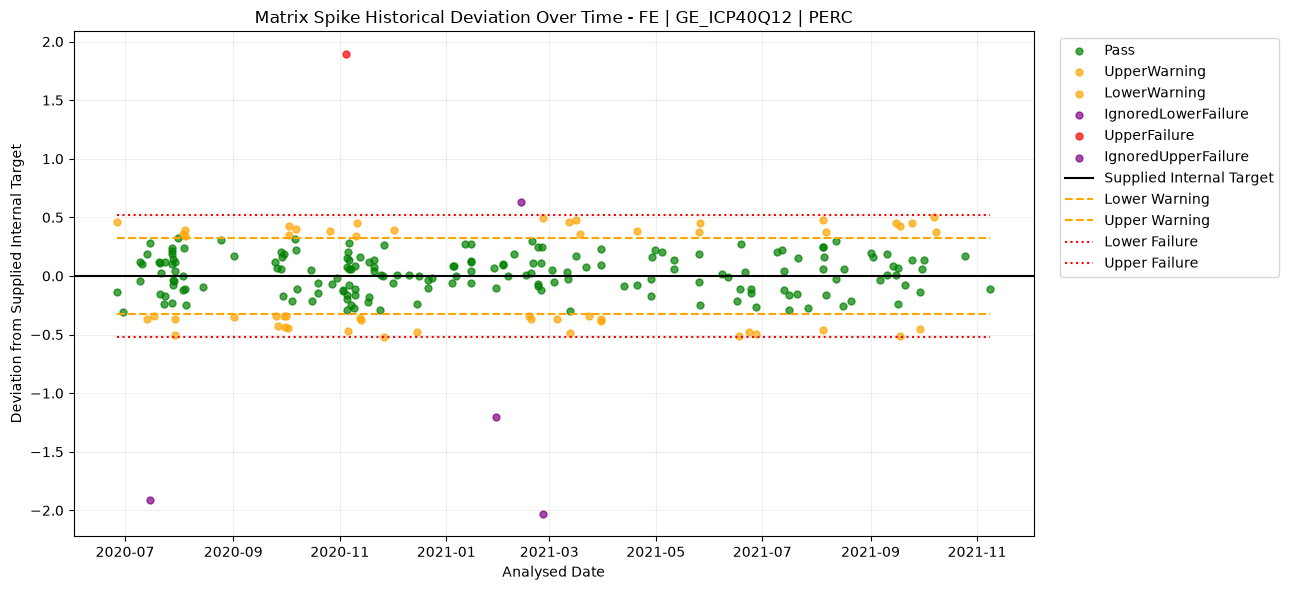

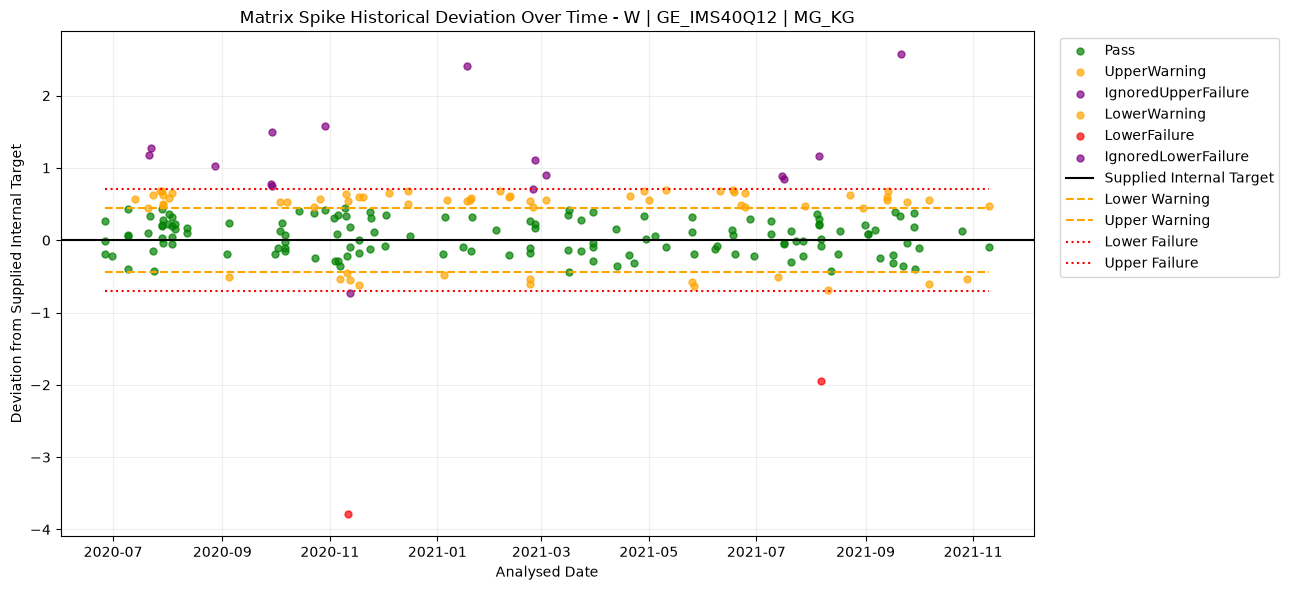

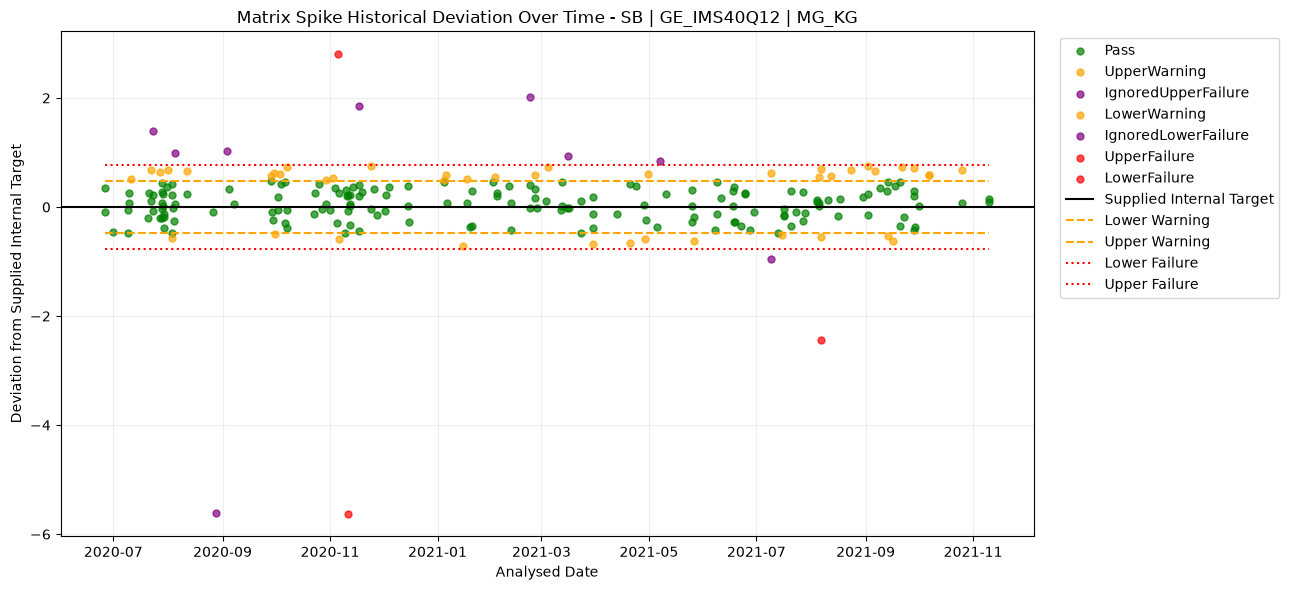

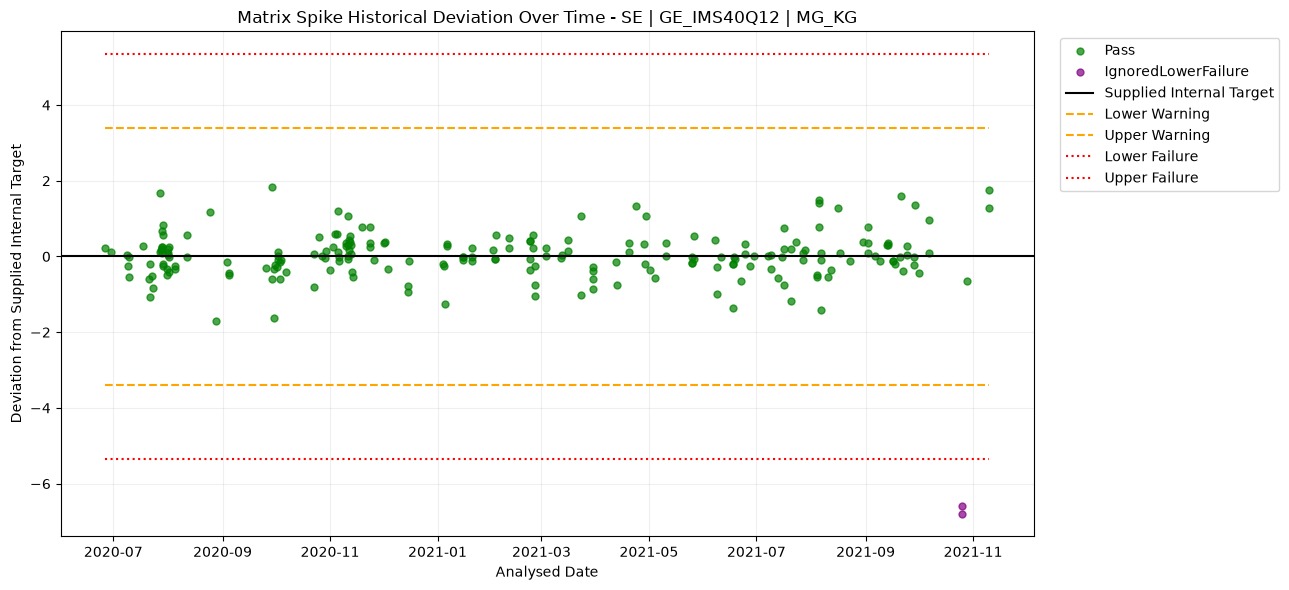

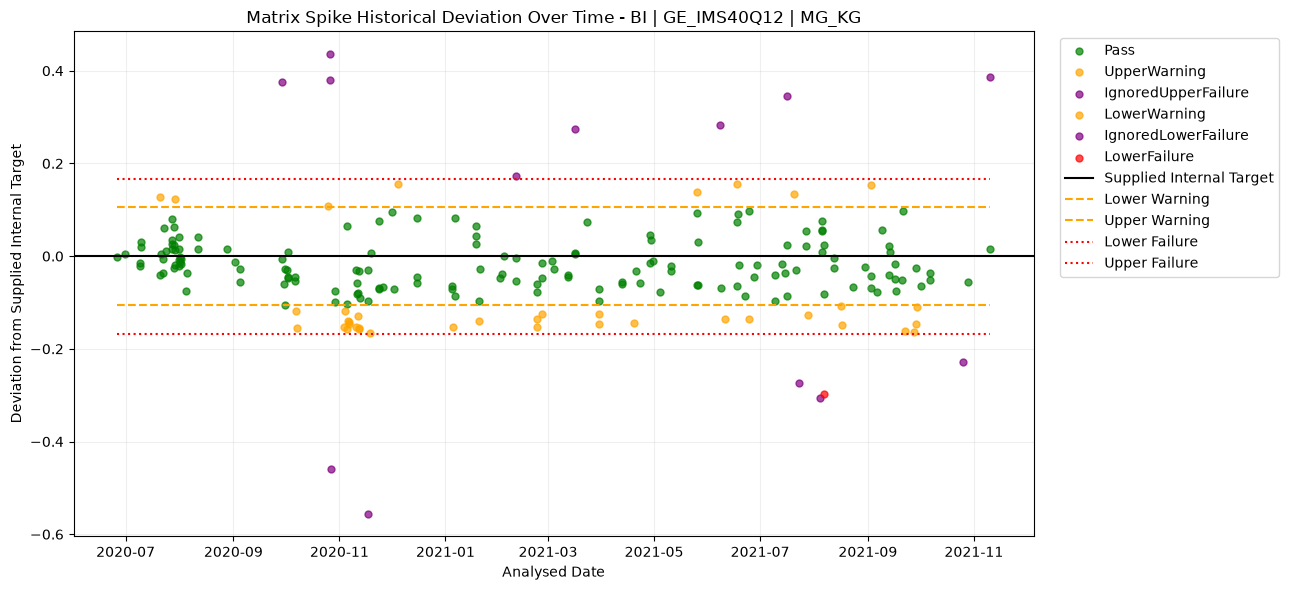

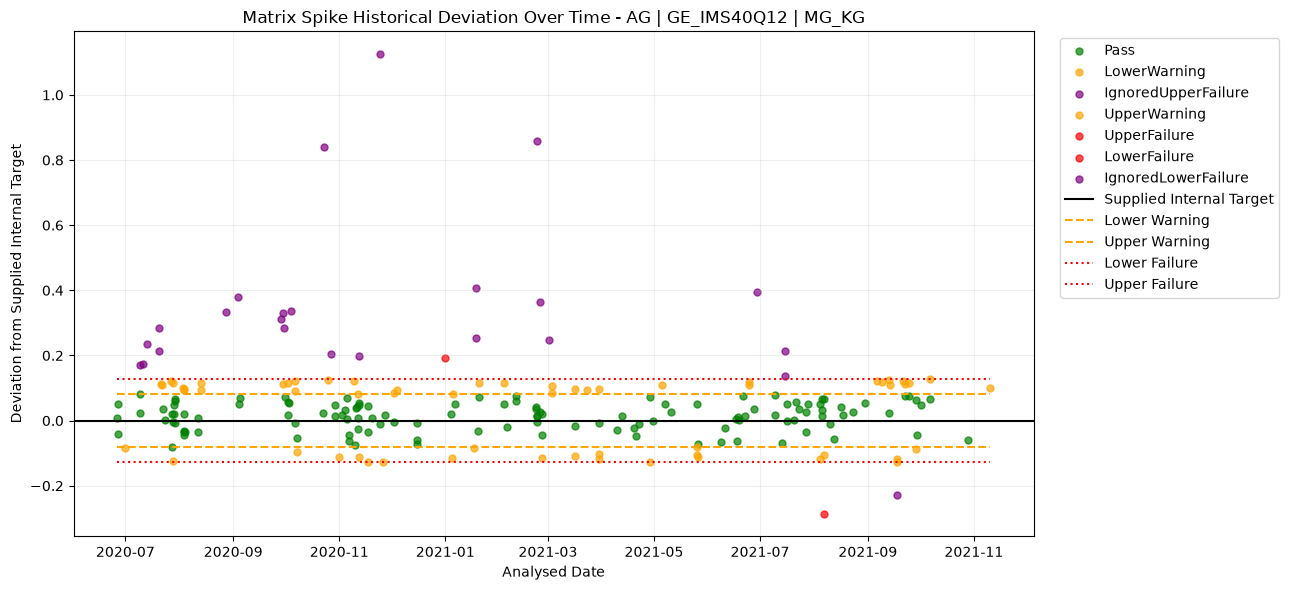

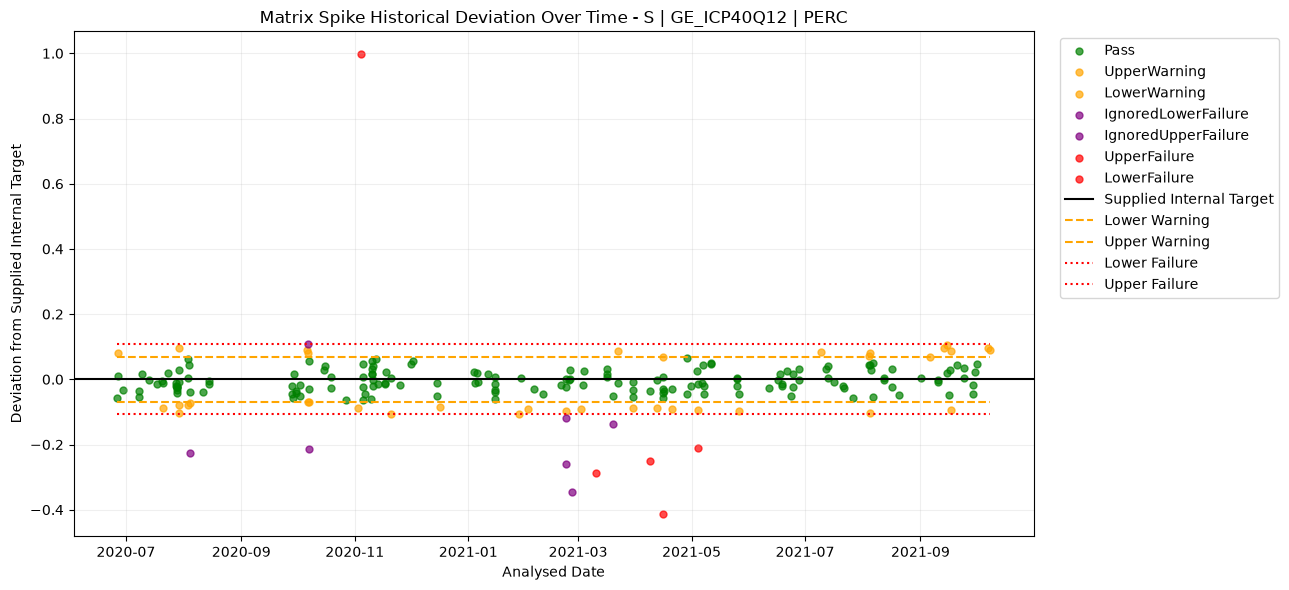

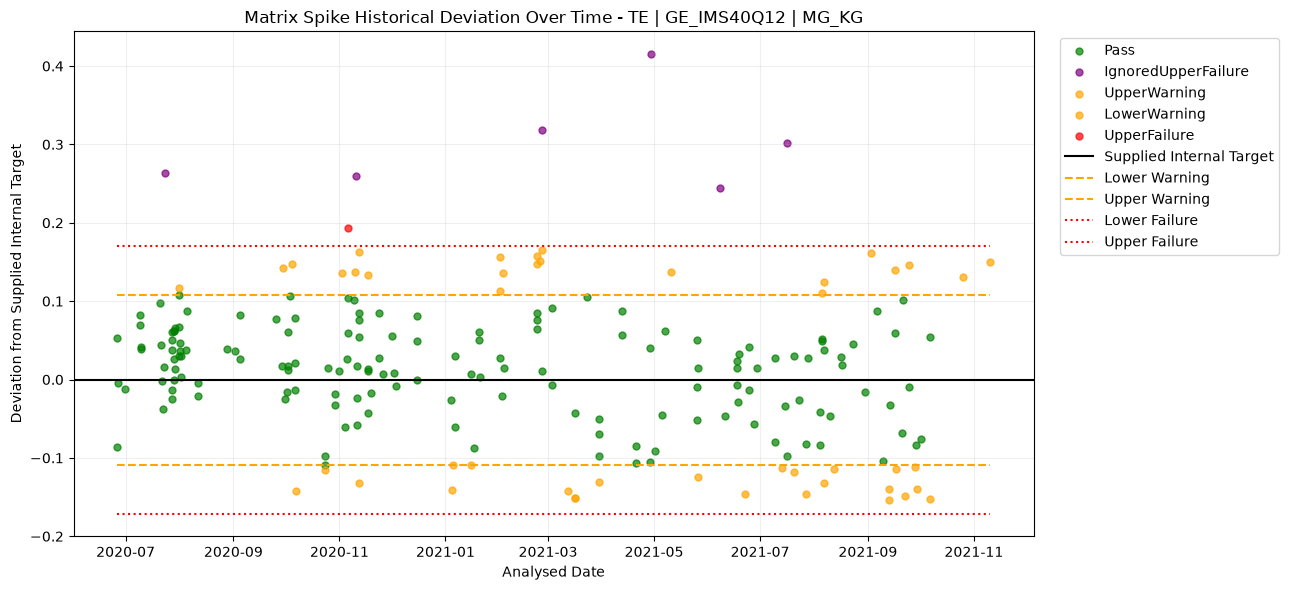

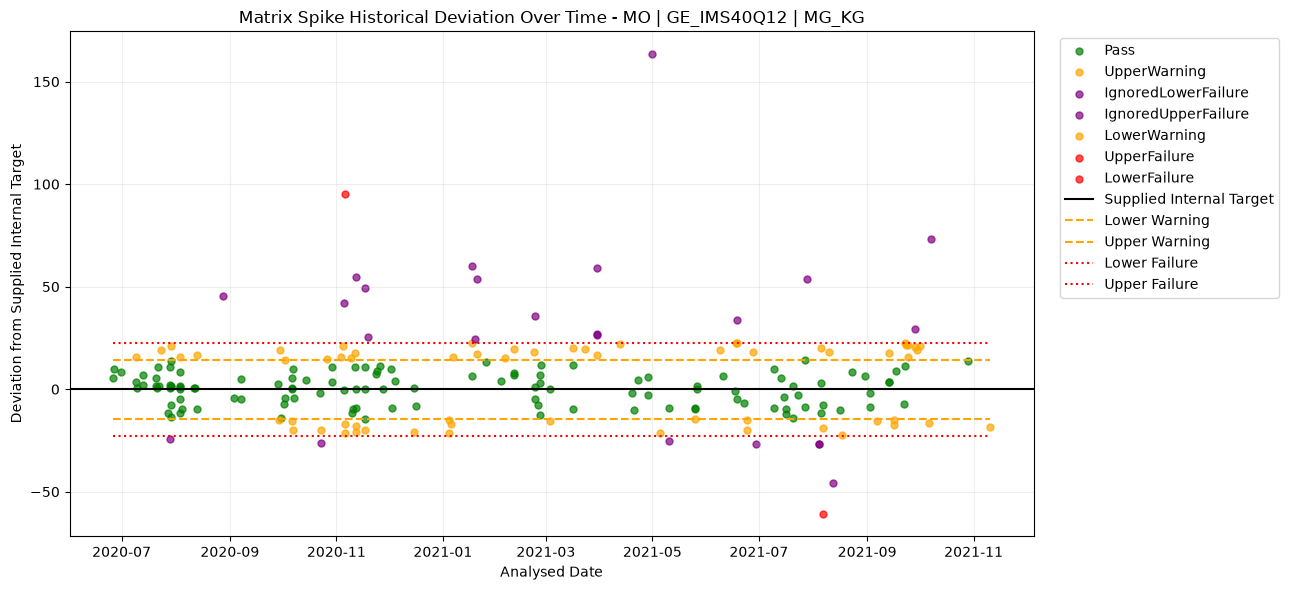

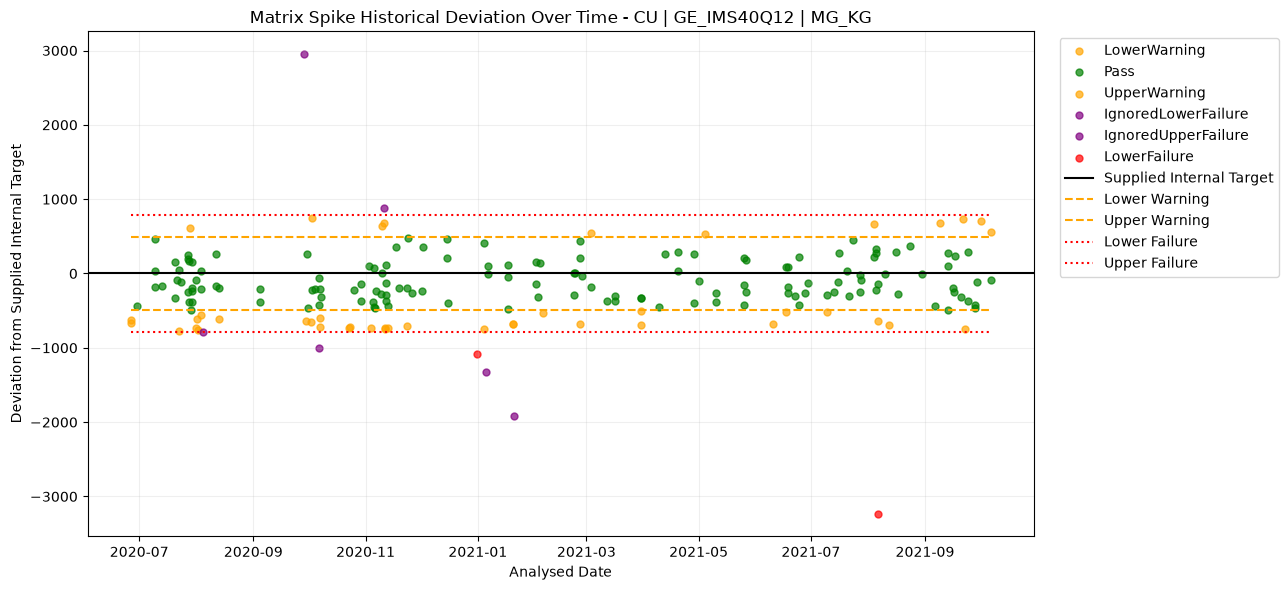

In [94]:
# Count the number of historical results in each available
# Scheme–Analyte–Unit context
group_counts = (
    ms_time
    .dropna(subset=["SCHEME_CODE", "UNIT_CODE"])
    .groupby(
        ["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE"]
    )
    .size()
    .reset_index(name="Records")
    .sort_values("Records", ascending=False)
)

# Plot the 10 groups with the most historical records
# for descriptive visualisation only
for _, row in group_counts.head(10).iterrows():

    plot_ms_deviation(
        ms_time,
        row["SCHEME_CODE"],
        row["ANALYTE_CODE"],
        row["UNIT_CODE"]
    )

## 7. Summary

This notebook visualises the historical behaviour of Matrix Spike results relative to the supplied internal target for individual analytical contexts.

The plots show how deviation from the supplied target changes through time, together with the supplied status, warning boundaries, and failure boundaries.

Recovery percentage is not analysed directly because the supplied Matrix Spike data does not contain the recovery information required for that calculation.

